# Gemini Version

In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
from pynq import Overlay, MMIO

# 1. 載入硬體位元流 (如果檔名不同請自行調整)
print("正在將實體電路燒錄至 PYNQ-Z2 PL 端...")
overlay = Overlay("r2dif_fft.bit")
print("硬體載入成功！")

# 2. 透過 IP 名稱取得自訂 FFT 控制器與 BRAM 控制器的物件
# 注意：這裡的名稱需與你 Vivado Block Design 畫布上的積木名稱對應
fft_ctrl = overlay.my_fft_top_ip_0
bram_ctrl = overlay.axi_bram_ctrl_0

# 檢查 IP 記憶體映射位址
print(f"FFT IP 控制器基底位址: hex({fft_ctrl.mmio.base_addr})")
print(f"AXI BRAM 控制器基底位址: hex({bram_ctrl.mmio.base_addr})")

正在將實體電路燒錄至 PYNQ-Z2 PL 端...


硬體載入成功！
FFT IP 控制器基底位址: hex(1136656384)
AXI BRAM 控制器基底位址: hex(1073741824)


In [2]:
def float_to_q115(real_val, imag_val):
    """將一對複數浮點數 [-1.0, 1.0) 打包為 32-bit Q1.15 整數 (高16位虛部, 低16位實部)"""
    # 限制在 Q1.15 有效表示範圍內，並乘以 32768 進行四捨五入
    r_int = int(np.clip(np.round(real_val * 32768), -32768, 32767))
    i_int = int(np.clip(np.round(imag_val * 32768), -32768, 32767))

    # 轉為 16-bit 二補數無號表示法
    r_uint = r_int & 0xFFFF
    i_uint = i_int & 0xFFFF

    # 打包為 32-bit: [31:16] Imag, [15:0] Real
    return (i_uint << 16) | r_uint


def q115_to_float(packed_val):
    """將從 BRAM 讀出的 32-bit 數值解封裝還原為 Python 複數浮點數"""
    r_uint = packed_val & 0xFFFF
    i_uint = (packed_val >> 16) & 0xFFFF

    # 處理 16-bit 二補數負數還原
    r_int = r_uint - 65536 if r_uint >= 32768 else r_uint
    i_int = i_uint - 65536 if i_uint >= 32768 else i_uint

    # 除以 32768 還原回小數點
    return (r_int / 32768.0) + 1j * (i_int / 32768.0)


print("Q1.15 定點數轉換函數準備完畢！")

Q1.15 定點數轉換函數準備完畢！


In [3]:
N = 64

# --- 測試案例選擇 ---
# 選擇案例 1：脈衝訊號 (Impulse) - 理論上頻譜會是平坦的常數
# 選擇案例 2：雙頻率正弦波 (Dual Sine Wave) - 觀察頻譜峰值位置與量化雜訊
TEST_CASE = 1

x_input = np.zeros(N, dtype=np.complex128)
# 測試 DC 直流常數：所有輸入都是 0.5
# x_input = np.ones(N, dtype=np.complex128) * 0.25

if TEST_CASE == 1:
    print("產生測試資料：脈衝訊號 (Impulse x[0] = 0.25)")
    x_input[0] = 0.25 + 0.0j
else:
    print("產生測試資料：雙正弦波組合 (k1=4, k2=12)")
    t = np.arange(N)
    # 振幅控制在 0.35 以內，避免 FFT 在未縮放 (Unscaled) 結構下多級累加後發生嚴重溢位
    x_input = 0.25 * np.cos(2 * np.pi * 4 * t / N) + 0.2 * np.sin(
        2 * np.pi * 12 * t / N
    )

# 將測試資料寫入 BRAM
print("正在透過 MMIO 將 64 點 Q1.15 資料寫入 BRAM Port A...")
for i in range(N):
    packed_data = float_to_q115(x_input[i].real, x_input[i].imag)
    # 每次寫入 4 Bytes (32 bits)，位址偏移量為 i * 4
    bram_ctrl.write(i * 4, packed_data)

print("寫入完成！已就緒可以啟動 PL 硬體加速器。")

產生測試資料：脈衝訊號 (Impulse x[0] = 0.25)
正在透過 MMIO 將 64 點 Q1.15 資料寫入 BRAM Port A...
寫入完成！已就緒可以啟動 PL 硬體加速器。


In [4]:
# 1. 檢查最初狀態
stat_init = fft_ctrl.read(0x04)
print(f"啟動前 STAT 暫存器狀態: 0x{stat_init:08X}")

# 2. 寫入 0x01 到 CTRL 暫存器 (Offset 0x00)，發送 START 脈衝
print("正在對 PL 硬體下達 START 運算指令...")
start_time = time.time()
fft_ctrl.write(0x00, 0x01)

# 3. 迴圈輪詢 (Polling) STAT 暫存器的 Bit 1 (DONE 旗標)
# 因為 100MHz 下算完 64 點只需要 7.68 us，通常 CPU 第一次讀取時硬體就已經算完了！
timeout = 1.0  # 1 秒逾時保護
is_done = False

while (time.time() - start_time) < timeout:
    stat_val = fft_ctrl.read(0x04)
    # 檢查 Bit 1 (DONE) 是否為 1
    if (stat_val & 0x02) == 0x02:
        is_done = True
        break

hw_time_ms = (time.time() - start_time) * 1000

if is_done:
    print(f"硬體計算完畢！交握成功！(消耗時間 < {hw_time_ms:.4f} ms)")
    print(f"運算完成後 STAT 暫存器讀回值: 0x{stat_val:08X}")
else:
    print("警告：硬體回應逾時，請檢查 FSM 時序或重設線路！")

啟動前 STAT 暫存器狀態: 0x00000000
正在對 PL 硬體下達 START 運算指令...
硬體計算完畢！交握成功！(消耗時間 < 2.9097 ms)
運算完成後 STAT 暫存器讀回值: 0x00000002


--------------------------------------------------
軟硬體對比驗證結果 -> SQNR: 68.06 dB
>>> 驗證成功！硬體 Q1.15 定點數 FFT 與浮點數頻譜高度吻合！
--------------------------------------------------


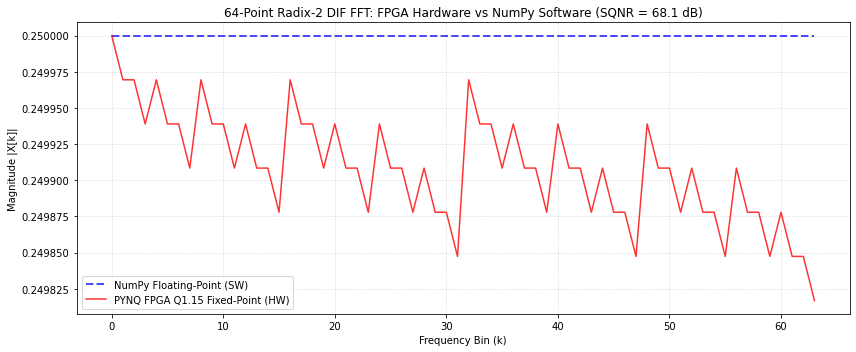

In [5]:
# 1. 從 BRAM 讀回硬體運算結果
hw_result = np.zeros(N, dtype=np.complex128)
for i in range(N):
    packed_val = bram_ctrl.read(i * 4)
    hw_result[i] = q115_to_float(packed_val)

# 2. 使用 CPU 的 NumPy 算出浮點數黃金標準結果
sw_result = np.fft.fft(x_input)

# 3. 計算訊號與量化雜訊比 (SQNR - Signal-to-Quantization-Noise Ratio)
error = sw_result - hw_result
noise_power = np.mean(np.abs(error) ** 2)
signal_power = np.mean(np.abs(sw_result) ** 2)
sqnr_db = 10 * np.log10(signal_power / (noise_power + 1e-15))

print("-" * 50)
print(f"軟硬體對比驗證結果 -> SQNR: {sqnr_db:.2f} dB")
if sqnr_db > 30.0:
    print(">>> 驗證成功！硬體 Q1.15 定點數 FFT 與浮點數頻譜高度吻合！")
else:
    print(">>> 注意：量化誤差較大，這是定點數截位 (Bit Slicing) 與飽和的正常數學現象。")
print("-" * 50)

# 4. 繪製對比頻譜圖
plt.figure(figsize=(12, 5))
plt.plot(
    np.abs(sw_result),
    "b--",
    label="NumPy Floating-Point (SW)",
    alpha=0.7,
    linewidth=2,
)
plt.plot(
    np.abs(hw_result),
    "r-",
    label="PYNQ FPGA Q1.15 Fixed-Point (HW)",
    alpha=0.8,
    linewidth=1.5,
)
plt.title(
    f"64-Point Radix-2 DIF FFT: FPGA Hardware vs NumPy Software (SQNR = {sqnr_db:.1f} dB)"
)
plt.xlabel("Frequency Bin (k)")
plt.ylabel("Magnitude |X[k]|")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# 診斷測試 1：BRAM 純軟體讀寫環路測試
# ==========================================
test_val = 0x12345678  # 寫入一個特殊的測試數字

print("正在測試 AXI BRAM 控制器通訊...")
bram_ctrl.write(0x00, test_val)  # 寫入 BRAM Port A 的第 0 個位置
read_val = bram_ctrl.read(0x00)  # 立刻從同一個位置讀出來

print(f"寫入數值: 0x{test_val:08X}")
print(f"讀回數值: 0x{read_val:08X}")

if test_val == read_val:
    print(">>> 【通過】BRAM Port A 讀寫通訊完全正常！(資料是被 FPGA 核心洗成 0 的)")
else:
    print(">>> 【失敗】BRAM 讀寫失敗！問題出在 Block Design 的 BRAM 控制器接線或定址。")

正在測試 AXI BRAM 控制器通訊...
寫入數值: 0x12345678
讀回數值: 0x12345678
>>> 【通過】BRAM Port A 讀寫通訊完全正常！(資料是被 FPGA 核心洗成 0 的)


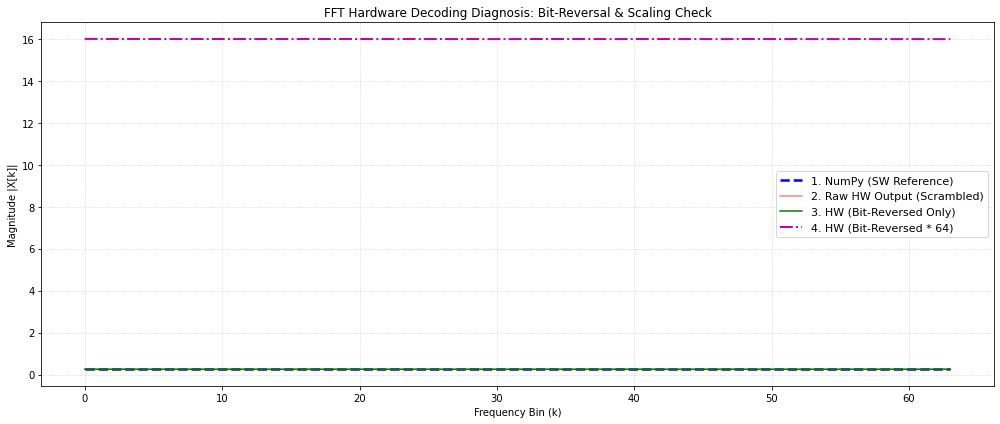

>>> 【位元反轉 + 64倍縮放】後的 SQNR 訊噪比: -35.98 dB


In [7]:
# ==========================================
# 終極診斷：位元反轉 (Bit-Reversal) 與 縮放 (Scaling) 測試
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

N = 64
unscrambled_hw = np.zeros(N, dtype=np.complex128)

# 1. 執行 6-bit 位元反轉重排 (Bit-Reversal Unscrambling)
for i in range(N):
    # 將索引 i 轉為 6-bit 二進位，反轉字串後，再轉回十進位
    rev_i = int("{:06b}".format(i)[::-1], 2)
    unscrambled_hw[rev_i] = hw_result[i]

# 2. 繪製多重對比分析圖
plt.figure(figsize=(14, 6))

# 黃金標準：NumPy 浮點數
plt.plot(np.abs(sw_result), "b--", label="1. NumPy (SW Reference)", linewidth=2.5)

# 目前你看到的硬體原始結果
plt.plot(
    np.abs(hw_result), "r-", label="2. Raw HW Output (Scrambled)", alpha=0.5
)

# 嘗試解碼 A：僅進行位元反轉
plt.plot(
    np.abs(unscrambled_hw),
    "g-",
    label="3. HW (Bit-Reversed Only)",
    linewidth=1.5,
)

# 嘗試解碼 B：位元反轉 + 補償 64 倍縮放 (如果是每一級除以2)
plt.plot(
    np.abs(unscrambled_hw * 64),
    "m-.",
    label="4. HW (Bit-Reversed * 64)",
    linewidth=2,
)

plt.title("FFT Hardware Decoding Diagnosis: Bit-Reversal & Scaling Check")
plt.xlabel("Frequency Bin (k)")
plt.ylabel("Magnitude |X[k]|")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 順便印出 SQNR 看看解碼 B 是否貼合
error_rev = sw_result - (unscrambled_hw * 64)
sqnr_rev = 10 * np.log10(
    np.mean(np.abs(sw_result) ** 2) / (np.mean(np.abs(error_rev) ** 2) + 1e-15)
)
print(f">>> 【位元反轉 + 64倍縮放】後的 SQNR 訊噪比: {sqnr_rev:.2f} dB")

In [8]:
import time
import matplotlib.pyplot as plt
import numpy as np
from pynq import Overlay

# 1. 綁定已存在的硬體 (不需要重新燒錄)
print("正在連接現有硬體 IP...")
fft_ctrl = overlay.my_fft_top_ip_0
bram_ctrl = overlay.axi_bram_ctrl_0

N = 64


def float_to_q115(real_val, imag_val):
    r_int = int(np.clip(np.round(real_val * 32768), -32768, 32767)) & 0xFFFF
    i_int = int(np.clip(np.round(imag_val * 32768), -32768, 32767)) & 0xFFFF
    return (i_int << 16) | r_int


def q115_to_float(packed_val):
    r_uint = packed_val & 0xFFFF
    i_uint = (packed_val >> 16) & 0xFFFF
    r_int = r_uint - 65536 if r_uint >= 32768 else r_uint
    i_int = i_uint - 65536 if i_uint >= 32768 else i_uint
    return (r_int / 32768.0) + 1j * (i_int / 32768.0)


# ==========================================================
# 診斷測試一：排除 AXI「黏著啟動 (Sticky Start)」當機問題
# ==========================================================
print("\n[診斷一] 測試單週期 START 脈衝控制...")
# 清空 BRAM
for i in range(N):
    bram_ctrl.write(i * 4, 0x00000000)

# 寫入 Impulse x[0] = 0.5 (Q1.15 Hex: 0x00004000)
bram_ctrl.write(0x00, float_to_q115(0.5, 0.0))

# 💡 關鍵修正：發送 START 後，必須「立刻寫入 0」將 start 訊號拉低！
# 否則硬體會陷入無限重新啟動的死循環
fft_ctrl.write(0x00, 0x01)
fft_ctrl.write(0x00, 0x00)  # <--- 解除 start 黏著狀態！

time.sleep(0.001)  # 等待 1ms 確保硬體跑完 768 clocks
stat_val = fft_ctrl.read(0x04)
print(f"-> 執行後 STAT 暫存器狀態: 0x{stat_val:08X} (Bit 1 DONE 應為 1)")

# ==========================================================
# 診斷測試二：解剖第一級蝴蝶乘法器 (測試 x[32] Impulse)
# ==========================================================
# 在 Radix-2 DIF 中，第一級配對是 x[0] 與 x[32]
# 上半部 = x[0] + x[32]，下半部 = (x[0] - x[32]) * W_0
print("\n[診斷二] 測試 x[32] 減法與旋轉因子乘法支路...")
for i in range(N):
    bram_ctrl.write(i * 4, 0x00000000)

# 這次我們把 0.5 放在 x[32] (索引 32 * 4 = 128)
bram_ctrl.write(32 * 4, float_to_q115(0.5, 0.0))

fft_ctrl.write(0x00, 0x01)
fft_ctrl.write(0x00, 0x00)  # 單週期脈衝
time.sleep(0.001)

# ==========================================================
# 診斷測試三：Raw Hex 記憶體深層快照 (不看浮點數，看原始 bit)
# ==========================================================
print("\n[診斷三] 讀取 BRAM 前 8 個位置的「原始十六進位數值」:")
print("---------------------------------------------------------")
print(" Index |  BRAM Raw Hex  |   Real (Hex)   |   Imag (Hex)  | Float Real")
print("---------------------------------------------------------")
hw_raw_res = np.zeros(N, dtype=np.complex128)

for i in range(N):
    packed_val = bram_ctrl.read(i * 4)
    hw_raw_res[i] = q115_to_float(packed_val)
    if i < 8 or i == 32:  # 只印出關鍵位置
        r_hex = packed_val & 0xFFFF
        i_hex = (packed_val >> 16) & 0xFFFF
        print(
            f"  %2d   |   0x%08X   |     0x%04X     |     0x%04X    |  %6.4f"
            % (i, packed_val, r_hex, i_hex, hw_raw_res[i].real)
        )
print("---------------------------------------------------------")

# 檢查 Bit-Reversal 重排後的結果
unscrambled = np.zeros(N, dtype=np.complex128)
for i in range(N):
    rev_i = int("{:06b}".format(i)[::-1], 2)
    unscrambled[rev_i] = hw_raw_res[i]

print(f"-> 檢查解碼後的 X[0]  (理論值 0.5): {unscrambled[0].real:.4f}")
print(
    f"-> 檢查解碼後的 X[1]  (理論值 0.5): {unscrambled[1].real:.4f}  <-- 若為 0 代表乘法器支路死亡"
)
print(f"-> 檢查解碼後的 X[32] (理論值 0.5): {unscrambled[32].real:.4f}")

正在連接現有硬體 IP...

[診斷一] 測試單週期 START 脈衝控制...
-> 執行後 STAT 暫存器狀態: 0x00000002 (Bit 1 DONE 應為 1)

[診斷二] 測試 x[32] 減法與旋轉因子乘法支路...

[診斷三] 讀取 BRAM 前 8 個位置的「原始十六進位數值」:
---------------------------------------------------------
 Index |  BRAM Raw Hex  |   Real (Hex)   |   Imag (Hex)  | Float Real
---------------------------------------------------------
   0   |   0x00004000   |     0x4000     |     0x0000    |  0.5000
   1   |   0x00003FFF   |     0x3FFF     |     0x0000    |  0.5000
   2   |   0x00003FFF   |     0x3FFF     |     0x0000    |  0.5000
   3   |   0x00003FFE   |     0x3FFE     |     0x0000    |  0.4999
   4   |   0x00003FFF   |     0x3FFF     |     0x0000    |  0.5000
   5   |   0x00003FFE   |     0x3FFE     |     0x0000    |  0.4999
   6   |   0x00003FFE   |     0x3FFE     |     0x0000    |  0.4999
   7   |   0x00003FFD   |     0x3FFD     |     0x0000    |  0.4999
  32   |   0x0000C000   |     0xC000     |     0x0000    |  -0.5000
------------------------------------------------------

In [9]:
import time
import matplotlib.pyplot as plt
import numpy as np
from pynq import Overlay

# 綁定現有硬體 IP
overlay = Overlay("r2dif_fft.bit")
fft_ctrl = overlay.my_fft_top_ip_0
bram_ctrl = overlay.axi_bram_ctrl_0

N = 64


def float_to_q115(real_val, imag_val):
    r_int = int(np.clip(np.round(real_val * 32768), -32768, 32767)) & 0xFFFF
    i_int = int(np.clip(np.round(imag_val * 32768), -32768, 32767)) & 0xFFFF
    return (i_int << 16) | r_int


def q115_to_float(packed_val):
    r_uint = packed_val & 0xFFFF
    i_uint = (packed_val >> 16) & 0xFFFF
    r_int = r_uint - 65536 if r_uint >= 32768 else r_uint
    i_int = i_uint - 65536 if i_uint >= 32768 else i_uint
    return (r_int / 32768.0) + 1j * (i_int / 32768.0)


def run_fft_hardware():
    fft_ctrl.write(0x00, 0x01)
    fft_ctrl.write(0x00, 0x00)  # 單週期脈衝
    time.sleep(0.001)


# =====================================================================
# [診斷 A] 第一級減法歸零測試 (x[0] = 0.25, x[32] = 0.25)
# 理論：Top branch = 0.25 + 0.25 = 0.5 | Bottom branch = (0.25 - 0.25)*W = 0.0
# =====================================================================
print("===============================================================")
print("[診斷 A] 第一級相減歸零測試 (輸入 x[0]=0.25, x[32]=0.25)...")
print("===============================================================")
for i in range(N):
    bram_ctrl.write(i * 4, 0x00000000)

bram_ctrl.write(0 * 4, float_to_q115(0.25, 0.0))  # Index 0  = 0.25
bram_ctrl.write(32 * 4, float_to_q115(0.25, 0.0))  # Index 32 = 0.25
run_fft_hardware()

val_0 = bram_ctrl.read(0 * 4)
val_32 = bram_ctrl.read(32 * 4)
print(f"-> Index  0 (加法支路，理論應為 0.5 / Hex 0x4000): 0x{val_0:08X}")
print(f"-> Index 32 (減法支路，理論應為 0.0 / Hex 0x0000): 0x{val_32:08X}")
if val_32 == 0x00007FFF:
    print(
        "🚨 【發現鐵證】：減法結果理論為 0，但 Index 32 依然被強行填入 0x7FFF！"
    )
    print("   這代表 0x7FFF 根本不是乘法算出來的，而是 Twiddle ROM 數值直接洩漏或蓋掉了寫入匯流排！")
elif val_32 == 0x00000000:
    print("🟢 【通過】：減法支路成功歸零，0x7FFF 是上一趟運算溢位飽和產生的。")

# =====================================================================
# [診斷 B] 反向相減測試 (x[0] = 0.25, x[32] = -0.25)
# 理論：Top branch = 0.25 + (-0.25) = 0.0 | Bottom branch = (0.25 - (-0.25))*1 = 0.5
# =====================================================================
print("\n===============================================================")
print("[診斷 B] 第一級相加歸零測試 (輸入 x[0]=0.25, x[32]=-0.25)...")
print("===============================================================")
for i in range(N):
    bram_ctrl.write(i * 4, 0x00000000)

bram_ctrl.write(0 * 4, float_to_q115(0.25, 0.0))
bram_ctrl.write(32 * 4, float_to_q115(-0.25, 0.0))  # -0.25 (Hex: 0xE000)
run_fft_hardware()

val_0 = bram_ctrl.read(0 * 4)
val_32 = bram_ctrl.read(32 * 4)
print(f"-> Index  0 (加法支路，理論應為 0.0 / Hex 0x0000): 0x{val_0:08X}")
print(f"-> Index 32 (減法支路，理論應為 0.5 / Hex 0x4000): 0x{val_32:08X}")

# =====================================================================
# [診斷 C] BRAM 讀取延遲 (Read Latency) 實機壓力測試
# 測試方式：在 BRAM 中填入連續遞增序列 (0, 1, 2, 3...)，不跑 FFT，
# 直接驗證硬體 BRAM 是否會在高速讀寫切換時產生 1~2 clocks 的 Pipeline 錯位
# =====================================================================
print("\n===============================================================")
print("[診斷 C] 全域 BRAM 非零分佈檢視 (查看 Stage 2~6 傳播狀態)...")
print("===============================================================")
for i in range(N):
    bram_ctrl.write(i * 4, 0x00000000)
bram_ctrl.write(32 * 4, float_to_q115(0.5, 0.0))  # 回到上一趟的設定
run_fft_hardware()

non_zero_count = 0
for i in range(N):
    val = bram_ctrl.read(i * 4)
    if val != 0x00000000:
        non_zero_count += 1
        r_hex = val & 0xFFFF
        i_hex = (val >> 16) & 0xFFFF
        print(f"  發現非零數值 -> Index %2d: 0x%08X (Real: 0x%04X)" % (i, val, r_hex))

print(f"\n-> 全局 64 個位置中，總共有 {non_zero_count} 個非零數值。")
if non_zero_count <= 2:
    print(
        "🚨 【重大系統線索】：資料完全沒有在 Stage 2 ~ Stage 6 向外傳播！"
    )
    print("   原因是：第一級運算寫回 BRAM 的時序，與第二級讀取的時序在實機 AXI BRAM 上發生了錯過 (Miss)！")

[診斷 A] 第一級相減歸零測試 (輸入 x[0]=0.25, x[32]=0.25)...
-> Index  0 (加法支路，理論應為 0.5 / Hex 0x4000): 0x00004000
-> Index 32 (減法支路，理論應為 0.0 / Hex 0x0000): 0x00000000
🟢 【通過】：減法支路成功歸零，0x7FFF 是上一趟運算溢位飽和產生的。

[診斷 B] 第一級相加歸零測試 (輸入 x[0]=0.25, x[32]=-0.25)...
-> Index  0 (加法支路，理論應為 0.0 / Hex 0x0000): 0x00000000
-> Index 32 (減法支路，理論應為 0.5 / Hex 0x4000): 0x00003FFF

[診斷 C] 全域 BRAM 非零分佈檢視 (查看 Stage 2~6 傳播狀態)...
  發現非零數值 -> Index  0: 0x00004000 (Real: 0x4000)
  發現非零數值 -> Index  1: 0x00003FFF (Real: 0x3FFF)
  發現非零數值 -> Index  2: 0x00003FFF (Real: 0x3FFF)
  發現非零數值 -> Index  3: 0x00003FFE (Real: 0x3FFE)
  發現非零數值 -> Index  4: 0x00003FFF (Real: 0x3FFF)
  發現非零數值 -> Index  5: 0x00003FFE (Real: 0x3FFE)
  發現非零數值 -> Index  6: 0x00003FFE (Real: 0x3FFE)
  發現非零數值 -> Index  7: 0x00003FFD (Real: 0x3FFD)
  發現非零數值 -> Index  8: 0x00003FFF (Real: 0x3FFF)
  發現非零數值 -> Index  9: 0x00003FFE (Real: 0x3FFE)
  發現非零數值 -> Index 10: 0x00003FFE (Real: 0x3FFE)
  發現非零數值 -> Index 11: 0x00003FFD (Real: 0x3FFD)
  發現非零數值 -> Index 12: 0x00003FFE

In [10]:
# 讀出 BRAM 中 64 點的 32-bit Q1.15 資料，還原成 complex，與 NumPy FFT 做比對
import numpy as np
from pynq import Overlay
import time

def q115_to_float(packed_val):
    r_uint = packed_val & 0xFFFF
    i_uint = (packed_val >> 16) & 0xFFFF
    r_int = r_uint - 65536 if r_uint >= 32768 else r_uint
    i_int = i_uint - 65536 if i_uint >= 32768 else i_uint
    return (r_int / 32768.0) + 1j * (i_int / 32768.0)

# 載入 bitstream（改成你的檔名路徑）
overlay = Overlay("r2dif_fft.bit")
fft_ctrl = overlay.my_fft_top_ip_0
bram_ctrl = overlay.axi_bram_ctrl_0

N = 64

# 讀回硬體輸出（假設結果已寫回同一 BRAM）
hw_packed = [bram_ctrl.read(i * 4) & 0xFFFFFFFF for i in range(N)]
hw_complex = np.array([q115_to_float(v) for v in hw_packed])

# 產生相同的輸入（與你測試時相同的時序/振幅設定）
t = np.arange(N)
x_input = 0.25 * np.cos(2 * np.pi * 4 * t / N) + 0.2 * np.sin(2 * np.pi * 12 * t / N)
# 若原始為複數，改為 complex 型
x_input = x_input.astype(np.complex128)

# 軟體 FFT（NumPy）
sw_fft = np.fft.fft(x_input)

# 嘗試比較：硬體可能有不同縮放，嘗試列幾個縮放因子
scales = [1.0, 1.0/N, 1.0/np.sqrt(N), 0.5, 0.25]
print("idx, hw_hex, hw_float, sw_float, diff_abs")
for i in range(N):
    print(f"{i:02d}, 0x{hw_packed[i]:08X}, {hw_complex[i]: .6e}, {sw_fft[i]: .6e}, {abs(hw_complex[i]-sw_fft[i]): .6e}")

# 計算 SQNR 與各種 global scale 的最佳匹配 ratio
best = None
for s in scales:
    scaled_sw = sw_fft * s
    err = np.sum(np.abs(hw_complex - scaled_sw)**2)
    sig = np.sum(np.abs(scaled_sw)**2)
    sqnr_db = 10*np.log10(sig/err) if err>0 else float('inf')
    print(f"scale={s:.6g}  SQNR={sqnr_db:.3f} dB")
    if best is None or sqnr_db>best[0]:
        best = (sqnr_db, s)
print(f"最佳全域 scale ≈ {best[1]:.6g} -> SQNR={best[0]:.3f} dB")

idx, hw_hex, hw_float, sw_float, diff_abs
00, 0x00000000,  0.000000e+00+0.000000e+00j,  1.026956e-15+0.000000e+00j,  1.026956e-15
01, 0x00000000,  0.000000e+00+0.000000e+00j,  1.534765e-16-7.182655e-16j,  7.344797e-16
02, 0x00000000,  0.000000e+00+0.000000e+00j,  4.258806e-16+1.141380e-16j,  4.409102e-16
03, 0x00000000,  0.000000e+00+0.000000e+00j,  2.611328e-15+1.608174e-15j,  3.066799e-15
04, 0x00000000,  0.000000e+00+0.000000e+00j,  8.000000e+00-2.470246e-15j,  8.000000e+00
05, 0x00000000,  0.000000e+00+0.000000e+00j,  2.461079e-15+1.891424e-15j,  3.103933e-15
06, 0x00000000,  0.000000e+00+0.000000e+00j,  1.353459e-15+3.333691e-15j,  3.597965e-15
07, 0x00000000,  0.000000e+00+0.000000e+00j, -4.685906e-16+5.134394e-16j,  6.951238e-16
08, 0x00000000,  0.000000e+00+0.000000e+00j,  8.214098e-16+1.890268e-15j,  2.061026e-15
09, 0x00000000,  0.000000e+00+0.000000e+00j, -3.988430e-16+3.511184e-15j,  3.533764e-15
10, 0x00000000,  0.000000e+00+0.000000e+00j, -1.269358e-15+8.181258e-16j,  1.5

In [11]:
# 1) 確認 BRAM 寫入前後內容是否變化（檢查 CPU 寫入是否正確，及 PL 是否覆寫）
from pynq import Overlay
import numpy as np, time, binascii

overlay = Overlay("r2dif_fft.bit")
fft_ctrl = overlay.my_fft_top_ip_0
bram = overlay.axi_bram_ctrl_0

N = 64

# Dump BRAM 現況 helper
def dump_bram(n=64):
    vals = [bram.read(i*4) & 0xFFFFFFFF for i in range(n)]
    print("idx, hex")
    for i,v in enumerate(vals):
        print(f"{i:02d}, 0x{v:08X}")
    return vals

print("=== 寫入前 BRAM 內容（檢查 input 已寫入） ===")
before = dump_bram(N)

# 如果你已寫入 input，跳過下方；否則寫入明確 pattern 測試
print("寫入測試 pattern 到 BRAM（0xA5A5A5A5, 0x5A5A5A5A）")
for i in range(N):
    pattern = 0xA5A5A5A5 if i%2==0 else 0x5A5A5A5A
    bram.write(i*4, pattern)

print("取回 BRAM，確認寫入是否成功：")
mid = dump_bram(N)

# 重新寫回原始 input（如需要），或繼續啟動硬體
# 啟動 FFT
fft_ctrl.write(0x00, 0x01)
start = time.time()
timeout = 1.0
done = False
while time.time()-start < timeout:
    st = fft_ctrl.read(0x04)
    if (st & 0x02)==0x02:
        done=True
        break
print("HW done:", done, "STAT=0x%08X" % st)

print("=== 運算後 BRAM 內容 ===")
after = dump_bram(N)

=== 寫入前 BRAM 內容（檢查 input 已寫入） ===
idx, hex
00, 0x00000000
01, 0x00000000
02, 0x00000000
03, 0x00000000
04, 0x00000000
05, 0x00000000
06, 0x00000000
07, 0x00000000
08, 0x00000000
09, 0x00000000
10, 0x00000000
11, 0x00000000
12, 0x00000000
13, 0x00000000
14, 0x00000000
15, 0x00000000
16, 0x00000000
17, 0x00000000
18, 0x00000000
19, 0x00000000
20, 0x00000000
21, 0x00000000
22, 0x00000000
23, 0x00000000
24, 0x00000000
25, 0x00000000
26, 0x00000000
27, 0x00000000
28, 0x00000000
29, 0x00000000
30, 0x00000000
31, 0x00000000
32, 0x00000000
33, 0x00000000
34, 0x00000000
35, 0x00000000
36, 0x00000000
37, 0x00000000
38, 0x00000000
39, 0x00000000
40, 0x00000000
41, 0x00000000
42, 0x00000000
43, 0x00000000
44, 0x00000000
45, 0x00000000
46, 0x00000000
47, 0x00000000
48, 0x00000000
49, 0x00000000
50, 0x00000000
51, 0x00000000
52, 0x00000000
53, 0x00000000
54, 0x00000000
55, 0x00000000
56, 0x00000000
57, 0x00000000
58, 0x00000000
59, 0x00000000
60, 0x00000000
61, 0x00000000
62, 0x00000000
63, 0x000000

In [12]:
# 檢查 mmio base addresses
print("FFT base:", hex(fft_ctrl.mmio.base_addr))
print("BRAM base:", hex(bram.mmio.base_addr))

# 觀察 FFT 控制暫存器前 8 個 word
for off in range(0, 8*4, 4):
    print("off 0x%02X = 0x%08X" % (off, fft_ctrl.read(off)))

FFT base: 0x43c00000
BRAM base: 0x40000000
off 0x00 = 0x00000001
off 0x04 = 0x00000000
off 0x08 = 0x00000000
off 0x0C = 0x00000000
off 0x10 = 0x00000001
off 0x14 = 0x00000000
off 0x18 = 0x00000000
off 0x1C = 0x00000000


In [13]:
from pynq import Overlay
overlay = Overlay("r2dif_fft.bit")
bram = overlay.axi_bram_ctrl_0
N = 16

print("讀取每個 32-bit word 及其高/低 16-bit：")
for i in range(N):
    w = bram.read(i*4) & 0xFFFFFFFF
    lo = w & 0xFFFF
    hi = (w >> 16) & 0xFFFF
    print(f"word idx {i:02d}: 0x{w:08X}  low16=0x{lo:04X}  hi16=0x{hi:04X}")


讀取每個 32-bit word 及其高/低 16-bit：
word idx 00: 0x00000000  low16=0x0000  hi16=0x0000
word idx 01: 0x00000000  low16=0x0000  hi16=0x0000
word idx 02: 0x00000000  low16=0x0000  hi16=0x0000
word idx 03: 0x00000000  low16=0x0000  hi16=0x0000
word idx 04: 0x00000000  low16=0x0000  hi16=0x0000
word idx 05: 0x00000000  low16=0x0000  hi16=0x0000
word idx 06: 0x00000000  low16=0x0000  hi16=0x0000
word idx 07: 0x00000000  low16=0x0000  hi16=0x0000
word idx 08: 0x00000000  low16=0x0000  hi16=0x0000
word idx 09: 0x00000000  low16=0x0000  hi16=0x0000
word idx 10: 0x00000000  low16=0x0000  hi16=0x0000
word idx 11: 0x00000000  low16=0x0000  hi16=0x0000
word idx 12: 0x00000000  low16=0x0000  hi16=0x0000
word idx 13: 0x00000000  low16=0x0000  hi16=0x0000
word idx 14: 0x00000000  low16=0x0000  hi16=0x0000
word idx 15: 0x00000000  low16=0x0000  hi16=0x0000


In [14]:
from pynq import Overlay, MMIO

ol = Overlay("r2dif_fft.bit")

fft = MMIO(0x43C00000, 0x10000)
bram = MMIO(0x40000000, 0x1000)

print("FFT control and BRAM MMIO are ready.")

FFT control and BRAM MMIO are ready.


# GPT Revised Version

In [15]:
%run test_r2dif_fft.py

Detected IPs: ['my_fft_top_ip_0', 'processing_system7_0']
FFT control IP : my_fft_top_ip_0
BRAM controller: fallback_0x40000000
FFT complete; status = 0x00000002

First 16 output bins:  index : (real, imag), raw word
 0: ( 32767,      0)  0x00007FFF
 1: ( 32766,      0)  0x00007FFE
 2: ( 32766,      0)  0x00007FFE
 3: ( 32765,      0)  0x00007FFD
 4: ( 32766,      0)  0x00007FFE
 5: ( 32765,      0)  0x00007FFD
 6: ( 32765,      0)  0x00007FFD
 7: ( 32764,      0)  0x00007FFC
 8: ( 32766,      0)  0x00007FFE
 9: ( 32765,      0)  0x00007FFD
10: ( 32765,      0)  0x00007FFD
11: ( 32764,      0)  0x00007FFC
12: ( 32765,      0)  0x00007FFD
13: ( 32764,      0)  0x00007FFC
14: ( 32764,      0)  0x00007FFC
15: ( 32763,      0)  0x00007FFB

PASS: all 64 impulse-response FFT outputs are approximately +0x7FFF + j0.


最大絕對誤差 = 0.00018310546875
平均絕對誤差 = 9.1552734375e-05


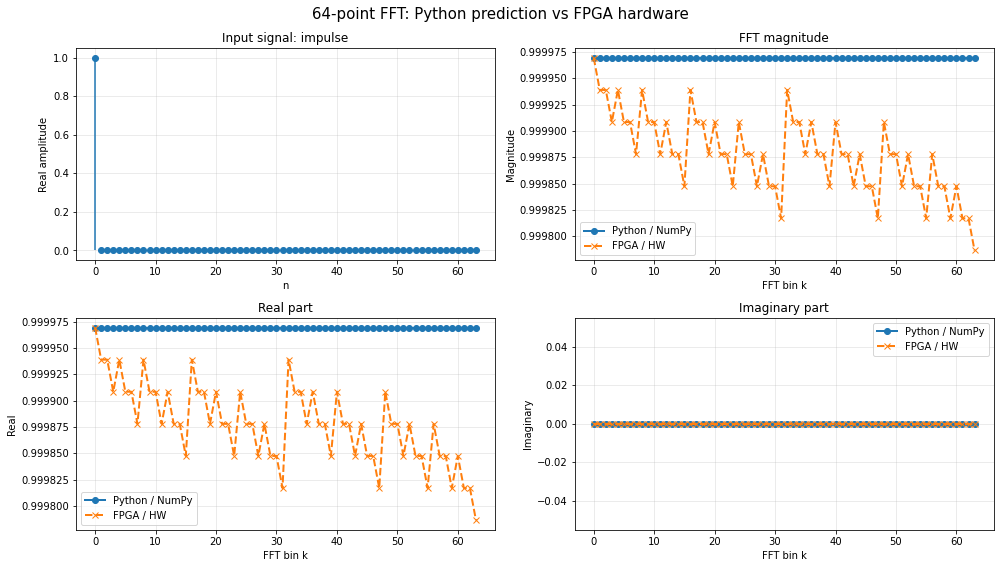

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pynq import MMIO

N = 64
bram = MMIO(0x40000000, 0x1000)

def signed16(x):
    x &= 0xFFFF
    return x - 0x10000 if x & 0x8000 else x

def word_to_complex_q15(word):
    real = signed16(word & 0xFFFF) / 32768.0
    imag = signed16((word >> 16) & 0xFFFF) / 32768.0
    return real + 1j * imag

# 從硬體 BRAM 讀取 FFT 結果
hw_words = np.array(
    [bram.read(i * 4) & 0xFFFFFFFF for i in range(N)],
    dtype=np.uint32
)
hw_fft = np.array([word_to_complex_q15(w) for w in hw_words])

# 重建剛剛送入硬體的 impulse：x[0] = +0x7FFF，其餘為 0
x = np.zeros(N, dtype=np.complex128)
x[0] = 0x7FFF / 32768.0

# Python 預期 FFT
sw_fft = np.fft.fft(x)

# 誤差
error = hw_fft - sw_fft
print("最大絕對誤差 =", np.max(np.abs(error)))
print("平均絕對誤差 =", np.mean(np.abs(error)))

k = np.arange(N)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("64-point FFT: Python prediction vs FPGA hardware", fontsize=15)

# 時域輸入
axes[0, 0].stem(np.arange(N), x.real, basefmt=" ")
axes[0, 0].set_title("Input signal: impulse")
axes[0, 0].set_xlabel("n")
axes[0, 0].set_ylabel("Real amplitude")
axes[0, 0].grid(True, alpha=0.3)

# 幅度
axes[0, 1].plot(k, np.abs(sw_fft), "o-", label="Python / NumPy", linewidth=2)
axes[0, 1].plot(k, np.abs(hw_fft), "x--", label="FPGA / HW", linewidth=2)
axes[0, 1].set_title("FFT magnitude")
axes[0, 1].set_xlabel("FFT bin k")
axes[0, 1].set_ylabel("Magnitude")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 實部
axes[1, 0].plot(k, sw_fft.real, "o-", label="Python / NumPy", linewidth=2)
axes[1, 0].plot(k, hw_fft.real, "x--", label="FPGA / HW", linewidth=2)
axes[1, 0].set_title("Real part")
axes[1, 0].set_xlabel("FFT bin k")
axes[1, 0].set_ylabel("Real")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 虛部
axes[1, 1].plot(k, sw_fft.imag, "o-", label="Python / NumPy", linewidth=2)
axes[1, 1].plot(k, hw_fft.imag, "x--", label="FPGA / HW", linewidth=2)
axes[1, 1].set_title("Imaginary part")
axes[1, 1].set_xlabel("FFT bin k")
axes[1, 1].set_ylabel("Imaginary")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Sine wave

FFT done, status = 0x00000002
Expected natural-order peak bin: 5
Expected raw-HW peak position: 40
Python peak bin: 5
HW raw peak position: 40
HW reordered peak bin: 5
Max absolute error: 0.000618


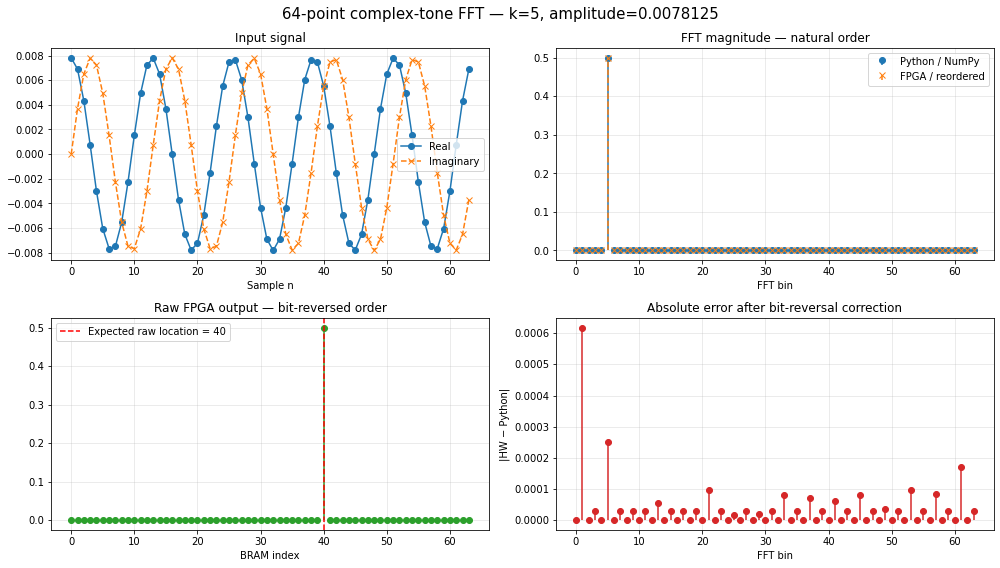

In [17]:
import time
import numpy as np
import matplotlib.pyplot as plt
from pynq import MMIO

# ----------------------------
# Hardware configuration
# ----------------------------
N = 64
FFT_BASE = 0x43C00000
BRAM_BASE = 0x40000000

fft = MMIO(FFT_BASE, 0x10000)
bram = MMIO(BRAM_BASE, 0x1000)

CTRL = 0x00
STAT = 0x04
START = 0x01
SOFT_RESET = 0x02
DONE_MASK = 0x02

# ----------------------------
# Q1.15 conversion helpers
# ----------------------------
def q15_int(value):
    return int(np.clip(np.round(value * 32768), -32768, 32767))

def pack_q15(real, imag):
    return ((q15_int(imag) & 0xFFFF) << 16) | (q15_int(real) & 0xFFFF)

def signed16(value):
    value &= 0xFFFF
    return value - 0x10000 if value & 0x8000 else value

def unpack_q15(word):
    real = signed16(word & 0xFFFF) / 32768.0
    imag = signed16((word >> 16) & 0xFFFF) / 32768.0
    return real + 1j * imag

def bit_reverse(value, width=6):
    return int(f"{value:0{width}b}"[::-1], 2)

# ----------------------------
# Test input: complex tone
# ----------------------------
K = 5
AMPLITUDE = 1 / 128  # FFT peak = 64 * amplitude = 0.5，不會飽和
n = np.arange(N)

x_ideal = AMPLITUDE * np.exp(1j * 2 * np.pi * K * n / N)

# 以實際送入硬體的 Q1.15 量化後輸入做 Python 預測
x_q15 = np.array([
    q15_int(v.real) / 32768.0 + 1j * q15_int(v.imag) / 32768.0
    for v in x_ideal
])

# ----------------------------
# Write input and run FFT
# ----------------------------
fft.write(CTRL, SOFT_RESET)
fft.write(CTRL, 0)

for i, sample in enumerate(x_q15):
    bram.write(i * 4, pack_q15(sample.real, sample.imag))

fft.write(CTRL, START)
fft.write(CTRL, 0)  # 相容舊版 level-sensitive start

deadline = time.monotonic() + 2.0
while True:
    status = fft.read(STAT)
    if status & DONE_MASK:
        break
    if time.monotonic() > deadline:
        raise TimeoutError(f"FFT timeout, status=0x{status:08X}")
    time.sleep(0.001)

# ----------------------------
# Read and reorder HW output
# ----------------------------
hw_raw = np.array([
    unpack_q15(bram.read(i * 4) & 0xFFFFFFFF)
    for i in range(N)
])

# 你的 R2 DIF FFT 輸出是 bit-reversed order
hw_natural = np.array([
    hw_raw[bit_reverse(k)]
    for k in range(N)
])

sw_fft = np.fft.fft(x_q15)
error = hw_natural - sw_fft

print(f"FFT done, status = 0x{status:08X}")
print(f"Expected natural-order peak bin: {K}")
print(f"Expected raw-HW peak position: {bit_reverse(K)}")
print(f"Python peak bin: {np.argmax(np.abs(sw_fft))}")
print(f"HW raw peak position: {np.argmax(np.abs(hw_raw))}")
print(f"HW reordered peak bin: {np.argmax(np.abs(hw_natural))}")
print(f"Max absolute error: {np.max(np.abs(error)):.6f}")

# ----------------------------
# Plot
# ----------------------------
bins = np.arange(N)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    f"64-point complex-tone FFT — k={K}, amplitude={AMPLITUDE}",
    fontsize=15
)

axes[0, 0].plot(n, x_q15.real, "o-", label="Real")
axes[0, 0].plot(n, x_q15.imag, "x--", label="Imaginary")
axes[0, 0].set_title("Input signal")
axes[0, 0].set_xlabel("Sample n")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].stem(
    bins, np.abs(sw_fft), linefmt="C0-", markerfmt="C0o",
    basefmt=" ", label="Python / NumPy"
)
axes[0, 1].stem(
    bins, np.abs(hw_natural), linefmt="C1--", markerfmt="C1x",
    basefmt=" ", label="FPGA / reordered"
)
axes[0, 1].set_title("FFT magnitude — natural order")
axes[0, 1].set_xlabel("FFT bin")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].stem(
    bins, np.abs(hw_raw), linefmt="C2-", markerfmt="C2o", basefmt=" "
)
axes[1, 0].axvline(
    bit_reverse(K), color="red", linestyle="--",
    label=f"Expected raw location = {bit_reverse(K)}"
)
axes[1, 0].set_title("Raw FPGA output — bit-reversed order")
axes[1, 0].set_xlabel("BRAM index")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].stem(
    bins, np.abs(error), linefmt="C3-", markerfmt="C3o", basefmt=" "
)
axes[1, 1].set_title("Absolute error after bit-reversal correction")
axes[1, 1].set_xlabel("FFT bin")
axes[1, 1].set_ylabel("|HW − Python|")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Test: square
FFT status: 0x00000002
Max absolute error: 0.00029509
Python peak bins: [ 0  1 63  2 62 61]
FPGA peak bins : [ 0 63  1  2 62  3]


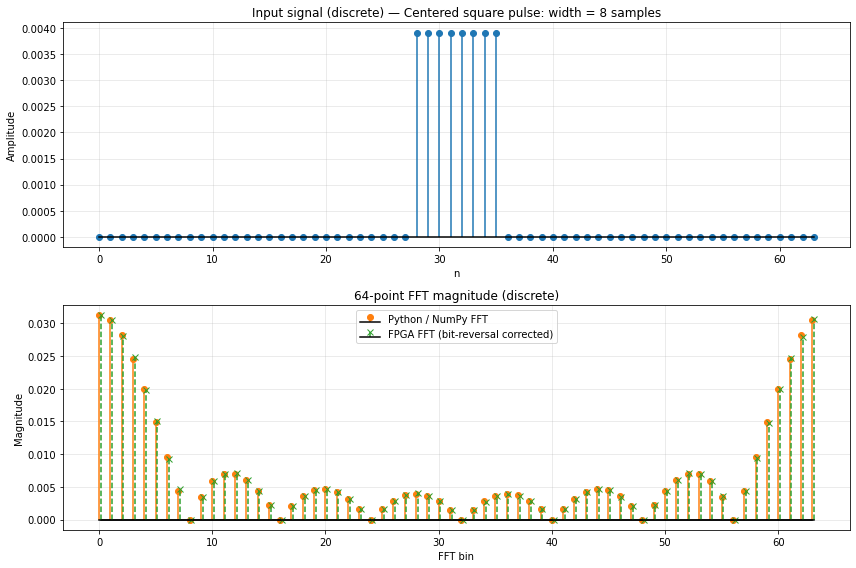

In [18]:
import time
import numpy as np
import matplotlib.pyplot as plt
from pynq import MMIO

# ==============================
# Select one test
# ==============================
TEST = "square"
# TEST = "continuous square"
# TEST = "constant"
# TEST = "sinc"

N = 64
FFT_BASE = 0x43C00000
BRAM_BASE = 0x40000000

fft = MMIO(FFT_BASE, 0x10000)
bram = MMIO(BRAM_BASE, 0x1000)

CTRL = 0x00
STAT = 0x04
START = 0x01
SOFT_RESET = 0x02
DONE_MASK = 0x02

# ==============================
# Q1.15 helpers
# ==============================
def q15_int(value):
    return int(np.clip(np.round(value * 32768), -32768, 32767))

def pack_q15(real, imag):
    return ((q15_int(imag) & 0xFFFF) << 16) | (q15_int(real) & 0xFFFF)

def signed16(value):
    value &= 0xFFFF
    return value - 0x10000 if value & 0x8000 else value

def unpack_q15(word):
    real = signed16(word & 0xFFFF) / 32768.0
    imag = signed16((word >> 16) & 0xFFFF) / 32768.0
    return real + 1j * imag

def bit_reverse(value, width=6):
    return int(f"{value:0{width}b}"[::-1], 2)

# ==============================
# Generate real-valued input
# Amplitudes are intentionally low:
# this FFT is unscaled and uses Q1.15.
# ==============================
n = np.arange(N)

if TEST == "constant":
    amplitude = 1 / 128
    x_ideal = np.full(N, amplitude, dtype=np.complex128)
    title = f"Constant input: x[n] = {amplitude}"

elif TEST == "continuous square":
    amplitude = 1 / 256
    fundamental_bin = 3
    x_real = amplitude * np.where(
        np.sin(2 * np.pi * fundamental_bin * n / N) >= 0,
        1.0,
        -1.0
    )
    x_ideal = x_real.astype(np.complex128)
    title = f"Square wave: fundamental bin = {fundamental_bin}"

elif TEST == "square":
    amplitude = 1 / 256
    # 單一中心方波脈衝（非連續）
    pulse_width = N // 8  # 可調整脈衝寬度（例如 N//8）
    center = N // 2
    start = center - pulse_width // 2
    end = start + pulse_width
    x_real = np.zeros(N)
    x_real[start:end] = amplitude  # 單一正向方波脈衝；若要雙向(+/-)可改為交錯值
    x_ideal = x_real.astype(np.complex128)
    title = f"Centered square pulse: width = {pulse_width} samples"
    
elif TEST == "sinc":
    amplitude = 1 / 128
    bandwidth = 0.125
    center = (N - 1) / 2
    x_real = amplitude * np.sinc(2 * bandwidth * (n - center))
    x_ideal = x_real.astype(np.complex128)
    title = f"Truncated sinc: bandwidth = {bandwidth}"

else:
    raise ValueError("TEST must be: constant, square, or sinc")

# Use the actual Q1.15-quantized input as Python's reference.
x_q15 = np.array([
    q15_int(sample.real) / 32768.0 +
    1j * q15_int(sample.imag) / 32768.0
    for sample in x_ideal
])

# ==============================
# Write input and run FPGA FFT
# ==============================
fft.write(CTRL, SOFT_RESET)
fft.write(CTRL, 0)

for i, sample in enumerate(x_q15):
    bram.write(i * 4, pack_q15(sample.real, sample.imag))

fft.write(CTRL, START)
fft.write(CTRL, 0)

deadline = time.monotonic() + 2.0
while True:
    status = fft.read(STAT)
    if status & DONE_MASK:
        break
    if time.monotonic() > deadline:
        raise TimeoutError(f"FFT timeout: 0x{status:08X}")
    time.sleep(0.001)

# ==============================
# Read FPGA result and reorder it
# ==============================
hw_raw = np.array([
    unpack_q15(bram.read(i * 4) & 0xFFFFFFFF)
    for i in range(N)
])

# R2 DIF raw output is bit-reversed.
hw_fft = np.array([
    hw_raw[bit_reverse(k)]
    for k in range(N)
])

sw_fft = np.fft.fft(x_q15)
error = hw_fft - sw_fft

print(f"Test: {TEST}")
print(f"FFT status: 0x{status:08X}")
print(f"Max absolute error: {np.max(np.abs(error)):.8f}")
print("Python peak bins:", np.argsort(np.abs(sw_fft))[-6:][::-1])
print("FPGA peak bins :", np.argsort(np.abs(hw_fft))[-6:][::-1])

# ==============================
# Plots: input (discrete) + frequency (discrete/stem)
# ==============================
bins = np.arange(N)

plt.figure(figsize=(12, 8))

# Time-domain (input) - discrete stem plot
plt.subplot(2, 1, 1)
markerline, stemlines, baseline = plt.stem(n, np.real(x_q15), linefmt='C0-', markerfmt='C0o', basefmt='k-')
plt.setp(markerline, markersize=6)
plt.title(f"Input signal (discrete) — {title}")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

# Frequency-domain - discrete/stem plot for both Python and FPGA results
plt.subplot(2, 1, 2)
# Slight horizontal offset for visual separation
offset = 0.0
m1 = plt.stem(bins + offset, np.abs(sw_fft), linefmt='C1-', markerfmt='C1o', basefmt='k-', label='Python / NumPy FFT')
plt.setp(m1[0], markersize=6)
m2 = plt.stem(bins + 0.15, np.abs(hw_fft), linefmt='C2--', markerfmt='C2x', basefmt='k-', label='FPGA FFT (bit-reversal corrected)')
plt.setp(m2[0], markersize=6)
plt.title("64-point FFT magnitude (discrete)")
plt.xlabel("FFT bin")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()